# Solving the TOV equation

## Setup EOS

In [1]:
# Load local package project environment 
using Pkg
Pkg.activate("./../..") 

using Plots
plotlyjs()

using DifferentialEquations
using Printf
using UniCon

using EOSeNS.TOV
using EOSeNS.NEOS

  Activating project at `~/Desktop/GitRepositories/EOSeNS`


WebIO._IJuliaInit()

In [2]:
bbl1_eos =  convertUnits(bblTableEOS(1), NuclearUnits())
bbl2_eos =  convertUnits(bblTableEOS(2), NuclearUnits())

BarotropicEOS: BBL2T EOS
n_data: 215 
-------------------|---------------------|---------------
Lables             :  min_val - max_val  :  Units 
-------------------|---------------------|---------------
electron_fraction  :  0.03403 - 0.1995   :  1 / 
pressure           :   0.5114 - 876.1    :  MeV^1 / fm^3 
proton_fraction    :  0.03403 - 0.3774   :  1 / 
energy_density     :    75.86 - 1749     :  MeV^1 / fm^3 
number_density     :     0.08 - 1.3      :  1 / fm^3 


In [3]:
bbl1_eos_wc = addCrustByJumping(bbl1_eos, 0.08)
bbl2_eos_wc = addCrustByJumping(bbl2_eos, 0.08)

BarotropicEOS: BBL2T EOS with BBPNV crust
n_data: 292 
----------------|---------------------|---------------
Lables          :  min_val - max_val  :  Units 
----------------|---------------------|---------------
pressure        :  6.304e-25 - 876.1    :  MeV^1 / fm^3 
energy_density  :  4.409e-12 - 1749     :  MeV^1 / fm^3 
number_density  :  4.73e-15 - 1.3      :  1 / fm^3 


In [4]:
crust_eos = convertUnits(bbpnvCrustEOS(), NuclearUnits())

BarotropicEOS: Baym-Bethte-Pethick-Negele-Vautherin EOS
n_data: 86 
---------------------|---------------------|---------------
Lables               :  min_val - max_val  :  Units 
---------------------|---------------------|---------------
pressure             :  6.304e-25 - 4.613    :  MeV^1 / fm^3 
adiabatic_index      :      NaN - NaN      :  1 / 
nucleus_mass_number  :      NaN - NaN      :  1 / 
number_of_protons    :      NaN - NaN      :  1 / 
energy_density       :  4.409e-12 - 285.8    :  MeV^1 / fm^3 
number_density       :  4.73e-15 - 0.2979   :  1 / fm^3 


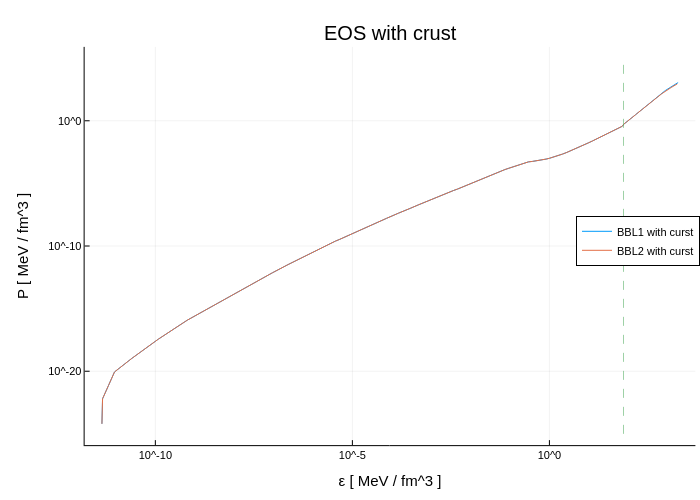

In [5]:
crust_eos = convertUnits(bbpnvCrustEOS(), NuclearUnits())
e_from_n = interpolated(crust_eos, "energy_density", "number_density")
crust_border = e_from_n(0.08)

plot(bbl1_eos_wc["energy_density"], bbl1_eos_wc["pressure"], label="BBL1 with curst", xscale = :log10, yscale = :log10, width = 1)
plot!(bbl2_eos_wc["energy_density"], bbl2_eos_wc["pressure"], label="BBL2 with curst", width = 1, legend = :right)
plot!([crust_border,crust_border], [1e-25, 1e5], line=(0.5,(:dash)), label="")
title!("EOS with crust")
xlabel!("ε [ MeV / fm^3 ]")
ylabel!("P [ MeV / fm^3 ]")

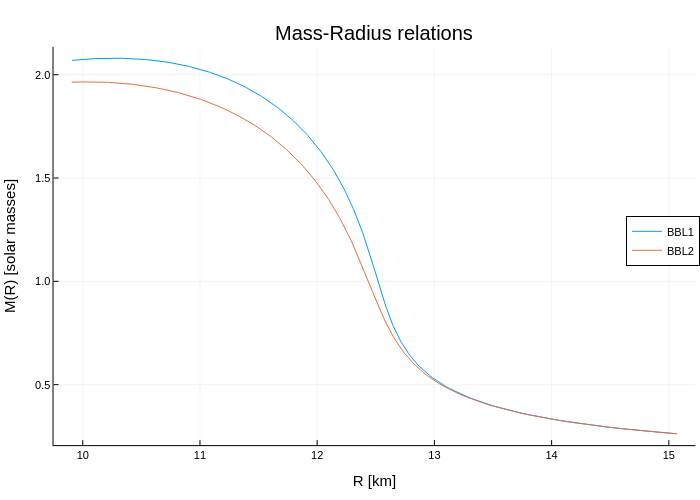

In [6]:
mass_1, radius_1, central_pressue_1 = getMassRadiusRelation(bbl1_eos_wc, pressure_min = 5e33)
mass_2, radius_2, central_pressue_2 = getMassRadiusRelation(bbl2_eos_wc, pressure_min = 5e33)

plot(radius_1, mass_1, label = "BBL1", legend = :right)
plot!(radius_2, mass_2, label = "BBL2")
title!("Mass-Radius relations")
ylabel!("M(R) [solar masses]")
xlabel!("R [km]")

In [7]:
idx_1 = findmin(abs.(radius_1 .- 12.0))[2]
println("M = $( @sprintf "%.4f" mass_1[idx_1])M_sol, R=$( @sprintf "%.4f" radius_1[idx_1])km, p_c = $( central_pressue_1[idx_1]/(10^10))GPa")
idx_2 = findmin(abs.(radius_2 .- 12.0))[2]
println("M = $( @sprintf "%.4f" mass_2[idx_2])M_sol, R=$( @sprintf "%.4f" radius_2[idx_2])km, p_c = $( central_pressue_2[idx_2]/(10^10))GPa")

M = 1.6526M_sol, R=11.9989km, p_c = 1.9637879002937995e25GPa
M = 1.4780M_sol, R=11.9964km, p_c = 1.5171811635662996e25GPa


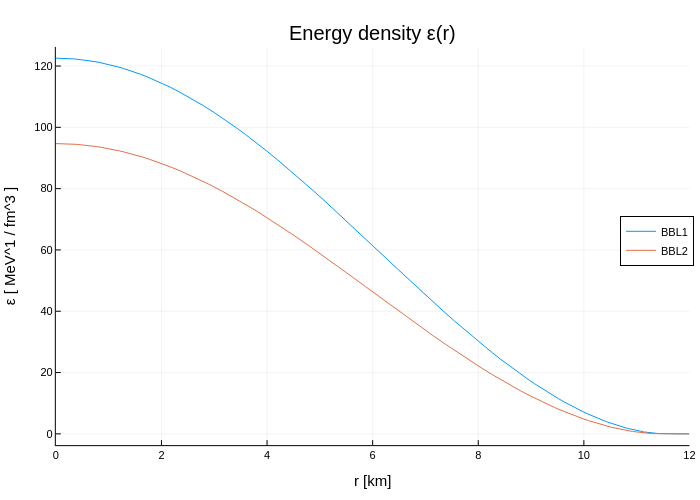

In [8]:
sol1 = solveTOVeq(setupTOVeq(bbl1_eos_wc, central_pressue_1[idx_1]), Tsit5(), reltol = 1e-8, dt = .01)
sol2 = solveTOVeq(setupTOVeq(bbl2_eos_wc, central_pressue_2[idx_2]), Tsit5(), reltol = 1e-8, dt = .01)

plot(sol1.r/10^5, convertValue(sol1.e, EnergyDensityDim(), CGS(), NuclearUnits()), label = "BBL1", legend = :right)
plot!(sol2.r/10^5, convertValue(sol2.e, EnergyDensityDim(), CGS(), NuclearUnits()), label = "BBL2")
#plot!(sol2.r[sol2.r .< 12], sol2.e[sol2.r .< 12], label = "BBL2")
xlims!((0,12))
title!("Energy density ε(r)")
ylabel!("ε [ MeV^1 / fm^3 ]")
xlabel!("r [km]")

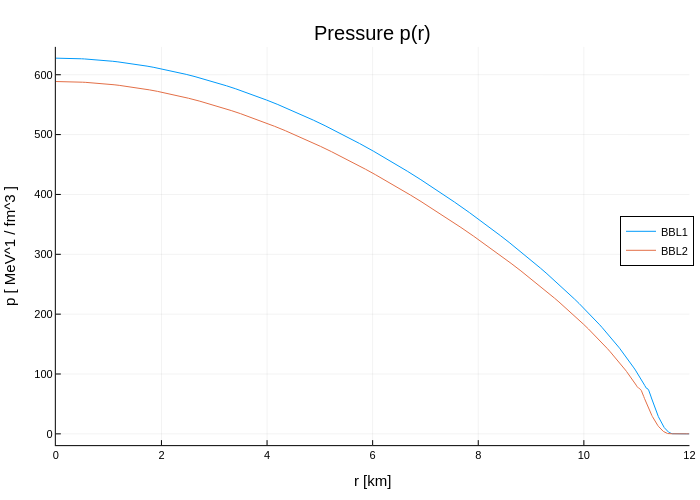

In [9]:
plot(sol1.r/10^5, convertValue(sol1.p, PressureDim(), CGS(), NuclearUnits()), label = "BBL1", legend = :right)
plot!(sol2.r/10^5, convertValue(sol2.p, PressureDim(), CGS(), NuclearUnits()), label = "BBL2")
#plot!(sol2.r[sol2.r .< 12], sol2.e[sol2.r .< 12], label = "BBL2")
xlims!((0,12))
title!("Pressure p(r)")
ylabel!("p [ MeV^1 / fm^3 ]")
xlabel!("r [km]")

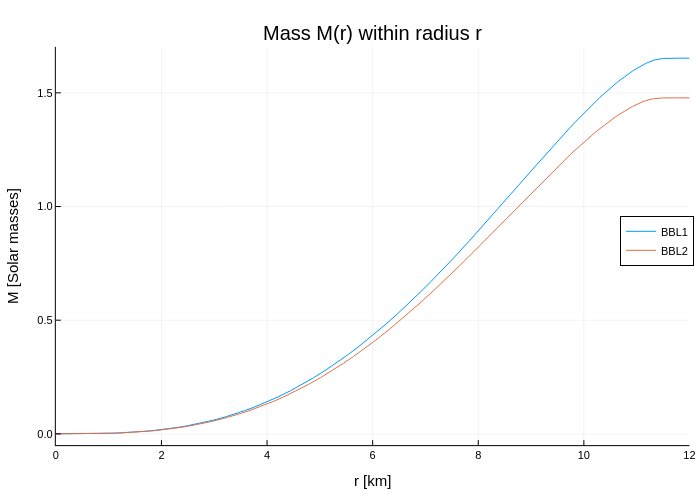

In [10]:
plot(sol1.r/10^5, convertValue(sol1.m, MassDim(), CGS(), AstroUnits()), label = "BBL1", legend = :right)
plot!(sol2.r/10^5, convertValue(sol2.m, MassDim(), CGS(), AstroUnits()), label = "BBL2")
#plot!(sol2.r[sol2.r .< 12], sol2.e[sol2.r .< 12], label = "BBL2")
xlims!((0,12))
title!("Mass M(r) within radius r")
ylabel!("M [Solar masses]")
xlabel!("r [km]")